### Ploting cellular expression of a gene

In [ ]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAexpression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAmetadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAumap.csv", index_col=0)

# Display General Data on the imported data. Run the import first
display(expr.columns)
display(expr.index)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata.obsm["X_umap"] = umap.values

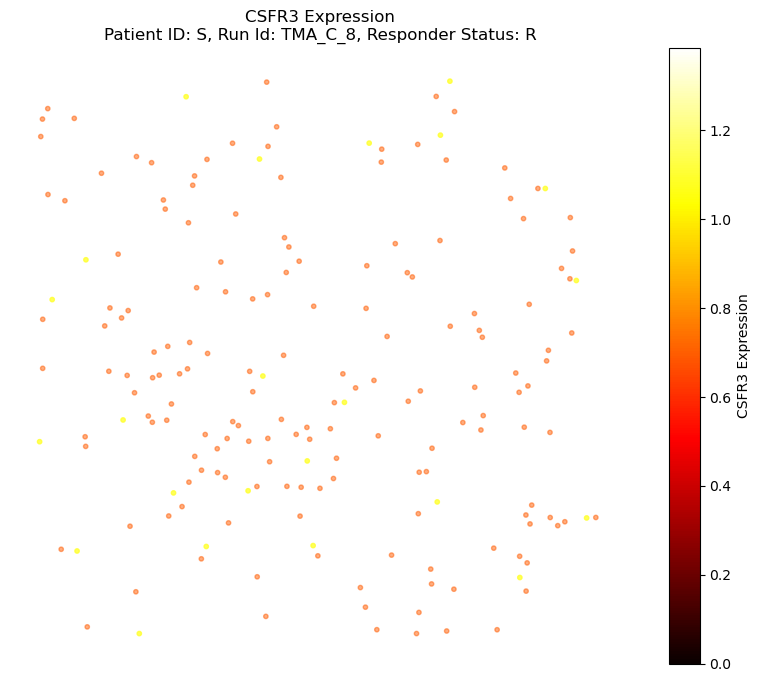

In [20]:
import matplotlib.pyplot as plt

# Get coordinates and expression values
coords = subset.obsm["spatial"]
expression = subset[:, "CSF3R"].X.toarray().flatten()  # or .X if dense

# Normalize expression to [0, 1] for alpha or color scaling
norm_expr = (expression - expression.min()) / (expression.max() - expression.min())

# Plot manually
plt.figure(figsize=(10, 8))
plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=expression,
    cmap="hot",           # or custom cmap
    s=10,
    alpha=norm_expr,      # makes low-expressers fade out
)
plt.gca().invert_yaxis()
plt.colorbar(label="CSFR3 Expression")
plt.title(f"CSFR3 Expression\nPatient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status: {response_status}")
plt.axis("off")
plt.show()

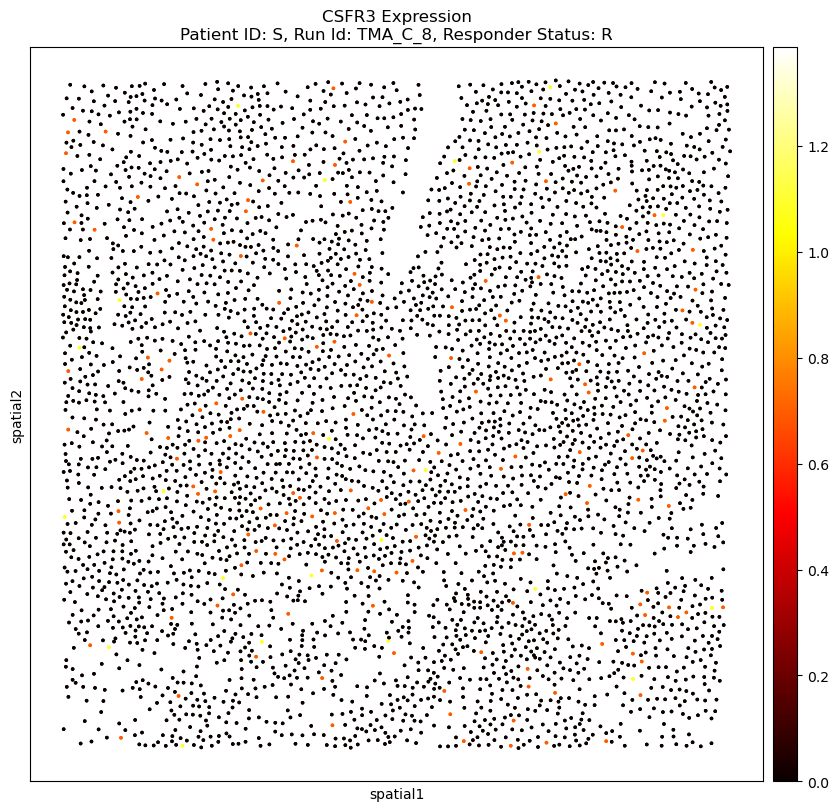

In [18]:
TMA_ids = ["C"]

for j in TMA_ids:
    for i in range(8, 9):
        cell_ID_like = f"TMA_{j}_FOV{i}(?!\d)"
        subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
        
        # Skip if no matching cells are found
        if subset.n_obs == 0:
            continue

        # Get the unique patient ID (assumes only one per subset)
        patient_id = subset.obs["PatientID"].unique()[0]
        response_status = subset.obs["Response"].unique()[0]

        # Plot expression of CSFR3
        sq.pl.spatial_scatter(
            subset,
            shape=None,
            color="CSF3R",  # this will plot expression levels of CSFR3
            size=10,
            title=f"CSFR3 Expression\nPatient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status: {response_status}",
            figsize=(10, 8),
            cmap="hot",  # or "magma", "plasma", "hot" etc. for brighter colors
            vmin=0,          # optional: clamp lower bound
            vmax=None,       # optional: clamp upper bound
            colorbar=True,   # show the expression color scale
        )

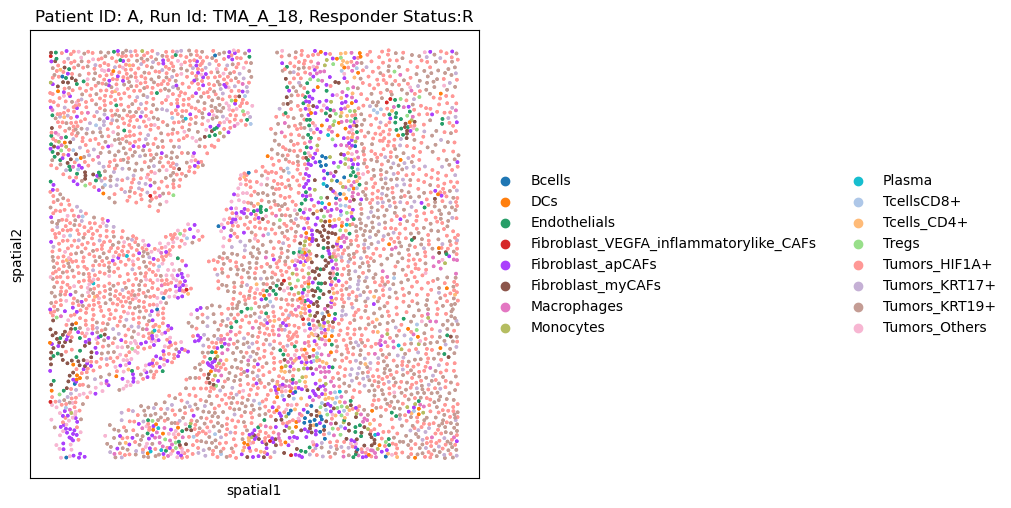

In [11]:
import squidpy as sq
import warnings
warnings.filterwarnings("ignore")

# Color scheme
BCELL_COLOR = "#48631d"
CD4_COLOR = "#42f5f5"
CD8_COLOR = "#4248f5"
DCs_COLOR = "#edbbbb"
FIBROBLASTS_COLOR = "#b08c68"
MACROPHAGE_COLOR = "#181459"
MONOCYTES_COLOR = "#1a8a2d"
NK_COLOR = "#f542bf"
PLASMA_COLOR = "#ec42f5"
TREG_COLOR = "#424ef5"
TUMOR_COLOR = "#57eba3"
ENDO_COLOR = "#b0a287"
OTHER_COLOR = "#d9d9d9"
FIBROBLAST_VEGFA_COLOR = "#b08c68"
FIBROBLAST_APCAFS_COLOR = "#b08c68"
FIBROBLAST_MYCAFS_COLOR = "#b08c68"
TUMORS_HIF1A_COLOR = "#57eba3"
TUMORS_KRT17_COLOR = "#57eba3"
TUMORS_KRT19_COLOR = "#57eba3"
TUMORS_OTHER_COLOR = "#57eba3"

# Full color mapping
cell_type_colors = {
    "Bcells": BCELL_COLOR,
    "TcellsCD8+": CD4_COLOR,
    "Tcells_CD4+": CD8_COLOR,
    "DCs": DCs_COLOR,
    "Fibroblasts/SMCs": FIBROBLASTS_COLOR,
    "Macrophages": MACROPHAGE_COLOR,
    "Monocytes": MONOCYTES_COLOR,
    "NK_cells": NK_COLOR,
    "Plasma": PLASMA_COLOR,
    "Tregs": TREG_COLOR,
    "Endothelials": ENDO_COLOR,
    "Fibroblast_myCAFs": FIBROBLAST_MYCAFS_COLOR,
    "Fibroblast_apCAFs": FIBROBLAST_APCAFS_COLOR,
    "Fibroblast_VEGFA_inflammatorylike_CAFs": FIBROBLAST_VEGFA_COLOR,
    "Tumors_HIF1A+": TUMORS_HIF1A_COLOR,
    "Tumors_KRT17+": TUMORS_KRT17_COLOR,
    "Tumors_KRT19+": TUMORS_KRT19_COLOR,
    "Tumors_Others": TUMORS_OTHER_COLOR
}

TMA_ids=["A"]

for j in TMA_ids:
    for i in range(18, 19):
        cell_ID_like =f"TMA_{j}_FOV{i}(?!\d)"
        subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
        
        # Skip if no matching cells are found
        if subset.n_obs == 0:
            continue
    
        # Get the unique patient ID (assumes only one per subset)
        patient_id = subset.obs["PatientID"].unique()[0]
        response_status = subset.obs["Response"].unique()[0]

        # Convert to categorical without setting all 12 types
        subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")
        
        # Plot with dynamic title
        sq.pl.spatial_scatter(
            subset,
            shape=None,
            color="annot_cluster2",
            size=10,
            title=f"Patient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status:{response_status}",
            figsize=(10, 8),  # or larger
            legend_loc='right margin'  # move legend out of plot area
        )